In [1]:
# Importar las librerías necesarias
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix

In [2]:
# URL del archivo en el bucket público de AWS
url = "https://hybridge-education-machine-learning-datasets.s3.us-east-1.amazonaws.com/Fraud.csv"
df = pd.read_csv(url)

In [3]:
df.head()

,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud
0,1,PAYMENT,9839.64,C1231006815,170136.0,160296.36,M1979787155,0.0,0.0,0,0
1,1,PAYMENT,1864.28,C1666544295,21249.0,19384.72,M2044282225,0.0,0.0,0,0
2,1,TRANSFER,181.00,C1305486145,181.0,0.00,C553264065,0.0,0.0,1,0
3,1,CASH_OUT,181.00,C840083671,181.0,0.00,C38997010,21182.0,0.0,1,0
4,1,PAYMENT,11668.14,C2048537720,41554.0,29885.86,M1230701703,0.0,0.0,0,0


In [4]:
len(df)

6362620

# ¡¡¡6,362,620 OBSERVACIONES!!!

In [5]:
# Revisar la distribución de transacciones fraudulentas y legítimas

print(df['isFraud'].value_counts())

print("\nPorcentaje de cada clase:")
print(df['isFraud'].value_counts(normalize=True) * 100)

isFraud
0    6354407
1       8213
Name: count, dtype: int64

Porcentaje de cada clase:
isFraud
0    99.870918
1     0.129082
Name: proportion, dtype: float64


In [6]:
# Seleccionar las variables que utilizaremos para el modelo

features = [
    'step',
    'type',
    'amount',
    'oldbalanceOrg',
    'newbalanceOrig',
    'oldbalanceDest',
    'newbalanceDest',
    'isFlaggedFraud'
]

X = df[features]
y = df['isFraud']

# Convertir la variable categórica 'type' a variables binarias
X = pd.get_dummies(X, columns=['type'], drop_first=True)

print("Dimensiones de X:", X.shape)
print("Dimensiones de y:", y.shape)

Dimensiones de X: (6362620, 11)
Dimensiones de y: (6362620,)


In [7]:
# Dividir los datos en entrenamiento y prueba
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Datos de entrenamiento:", X_train.shape)
print("Datos de prueba:", X_test.shape)

print("\nFraudes en entrenamiento:")
print(y_train.value_counts())

print("\nFraudes en prueba:")
print(y_test.value_counts())

Datos de entrenamiento: (5090096, 11)
Datos de prueba: (1272524, 11)

Fraudes en entrenamiento:
isFraud
0    5083526
1       6570
Name: count, dtype: int64

Fraudes en prueba:
isFraud
0    1270881
1       1643
Name: count, dtype: int64


In [8]:
# Escalar las características numéricas

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Escalado completado.")
print("Dimensiones de X_train_scaled:", X_train_scaled.shape)
print("Dimensiones de X_test_scaled:", X_test_scaled.shape)

Escalado completado.
Dimensiones de X_train_scaled: (5090096, 11)
Dimensiones de X_test_scaled: (1272524, 11)


In [9]:
# Crear y entrenar el modelo de regresión logística

modelo = LogisticRegression(
    class_weight='balanced',
    max_iter=1000,
    random_state=42
)

modelo.fit(X_train_scaled, y_train)

print("Modelo entrenado correctamente.")

Modelo entrenado correctamente.


In [10]:
# Realizar predicciones sobre los datos de prueba

y_pred = modelo.predict(X_test_scaled)

print("Predicciones realizadas correctamente.")
print("Primeras 20 predicciones:")
print(y_pred[:20])

Predicciones realizadas correctamente.
Primeras 20 predicciones:
[0 0 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0]


In [11]:
# Evaluar el modelo

print("=== Reporte de clasificación ===")
print(classification_report(y_test, y_pred))

print("=== Matriz de confusión ===")
cm = confusion_matrix(y_test, y_pred)
print(cm)

=== Reporte de clasificación ===
              precision    recall  f1-score   support

           0       1.00      0.95      0.98   1270881
           1       0.03      0.97      0.05      1643

    accuracy                           0.95   1272524
   macro avg       0.51      0.96      0.51   1272524
weighted avg       1.00      0.95      0.97   1272524

=== Matriz de confusión ===
[[1209026   61855]
 [     42    1601]]


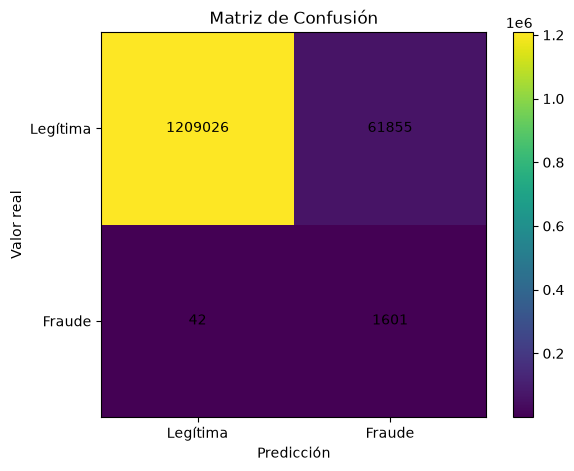

In [12]:
# Visualizar la matriz de confusión

plt.figure(figsize=(7, 5))

plt.imshow(cm)

plt.title('Matriz de Confusión')
plt.xlabel('Predicción')
plt.ylabel('Valor real')

plt.xticks([0, 1], ['Legítima', 'Fraude'])
plt.yticks([0, 1], ['Legítima', 'Fraude'])

for i in range(2):
    for j in range(2):
        plt.text(j, i, cm[i, j], ha='center', va='center')

plt.colorbar()
plt.show()